SIMULATED data: 2 sessions, 3 hidden states at (2.0, 5.0, 8.0) Hz, dwell 20 s
subject  date                 file
    sim sim00 simulated/session_00
    sim sim01 simulated/session_01

bin 20 ms | transform sqrt | 20 freqs 0.20-20.0 Hz | tau 1.0 s | 5-fold contiguous CV | representations: wavelet, lagged_rates

[1/2] sim sim00 | elapsed 0:07
    simulated epoch 15.0 min | 80 units | 44190 bins after trimming 8.1 s per end | loaded in 6.6s
    wavelet       40 PCs, d=1, N=200, M=3 (inner_simplex), |l2|=0.821, PR2=2, ARI 0.00 | 5:10
    lagged_rates  10 PCs, d=5, N=200, M=8 (inner_simplex), |l2|=0.709, PR2=119, ARI 0.67 | 1:08

[2/2] sim sim01 | elapsed 6:29, ~6:29 left
    simulated epoch 15.0 min | 80 units | 44190 bins after trimming 8.1 s per end | loaded in 4.2s
    wavelet       40 PCs, d=1, N=200, M=2 (inner_simplex), |l2|=0.881, PR2=3, ARI -0.00 | 5:37
    lagged_rates  10 PCs, d=5, N=200, M=2 (inner_simplex), |l2|=0.721, PR2=120, ARI 0.60 | 1:09

sweep finished in 13.3 min
subjec

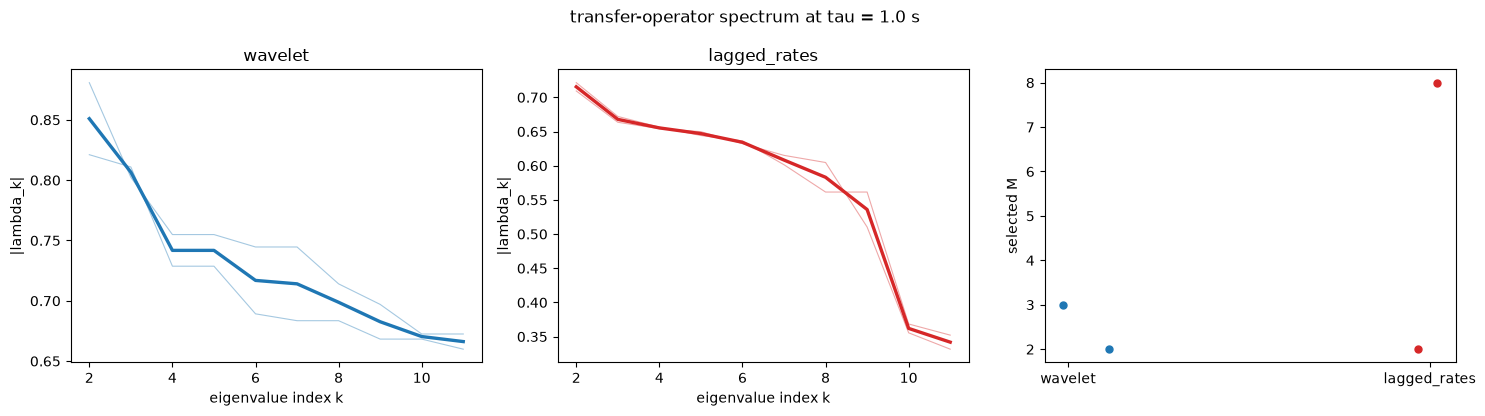

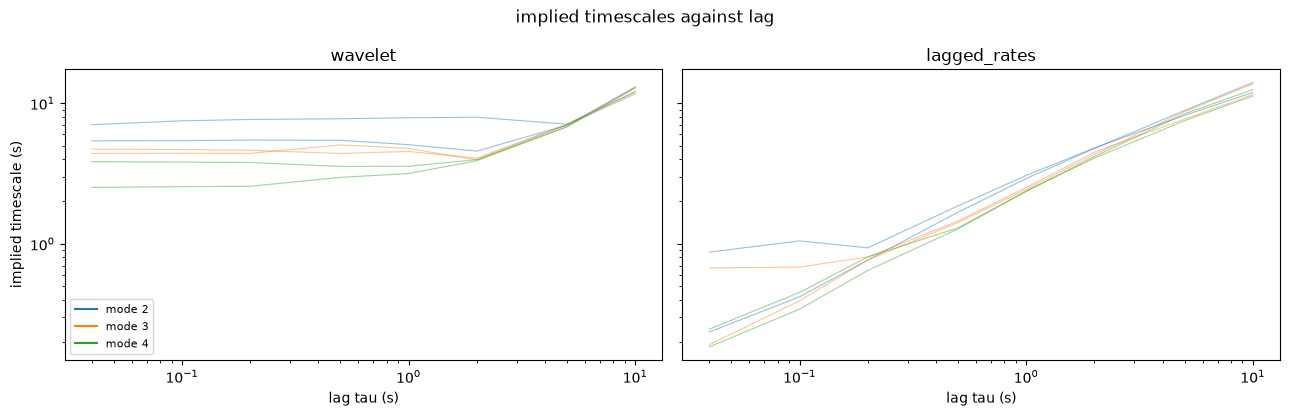

complex eigenvalues at the working lag
subject  date representation  mode  abs_lambda  cycle_hz
    sim sim00        wavelet     4       0.729     0.004
    sim sim01        wavelet     4       0.755     0.006


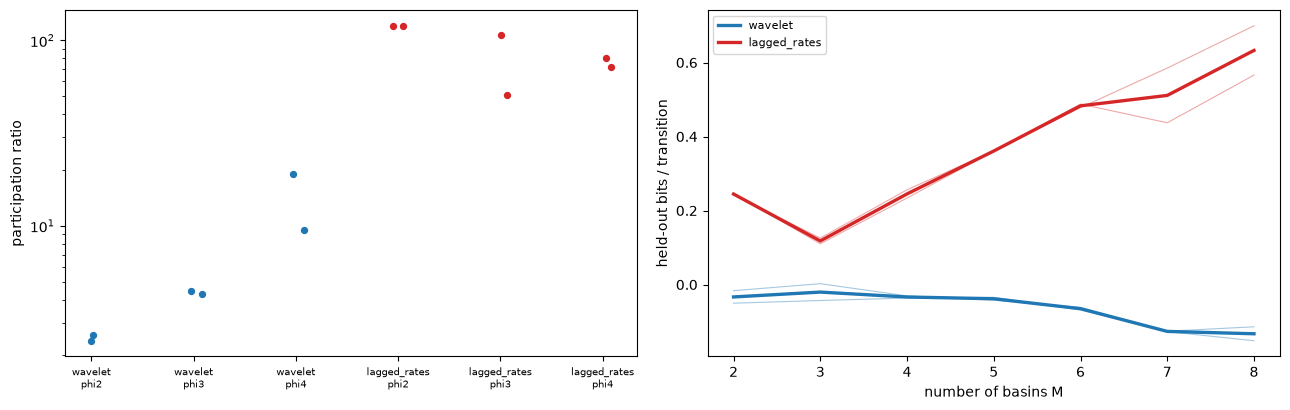

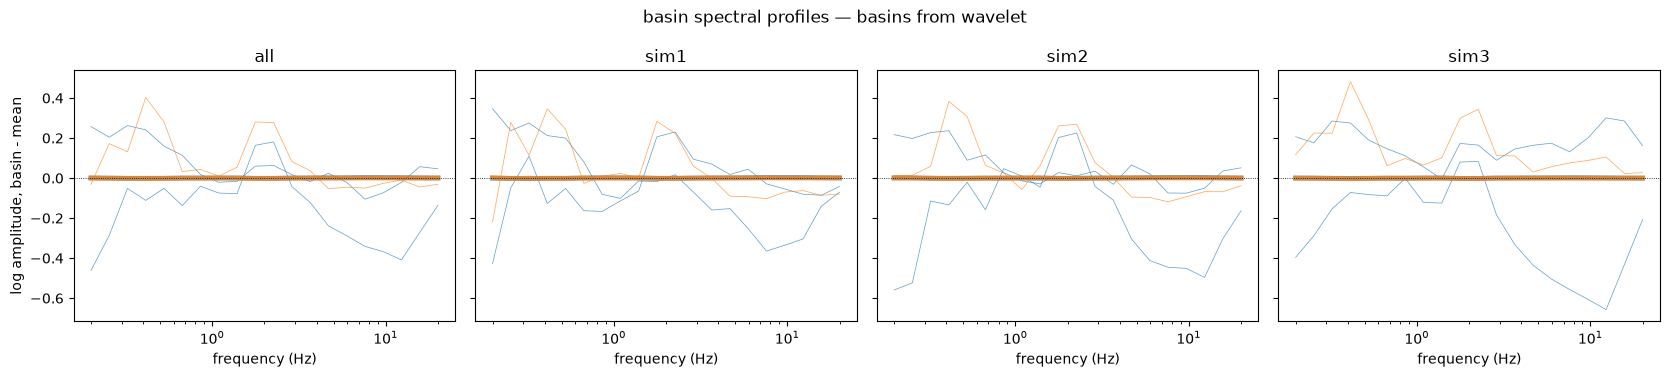

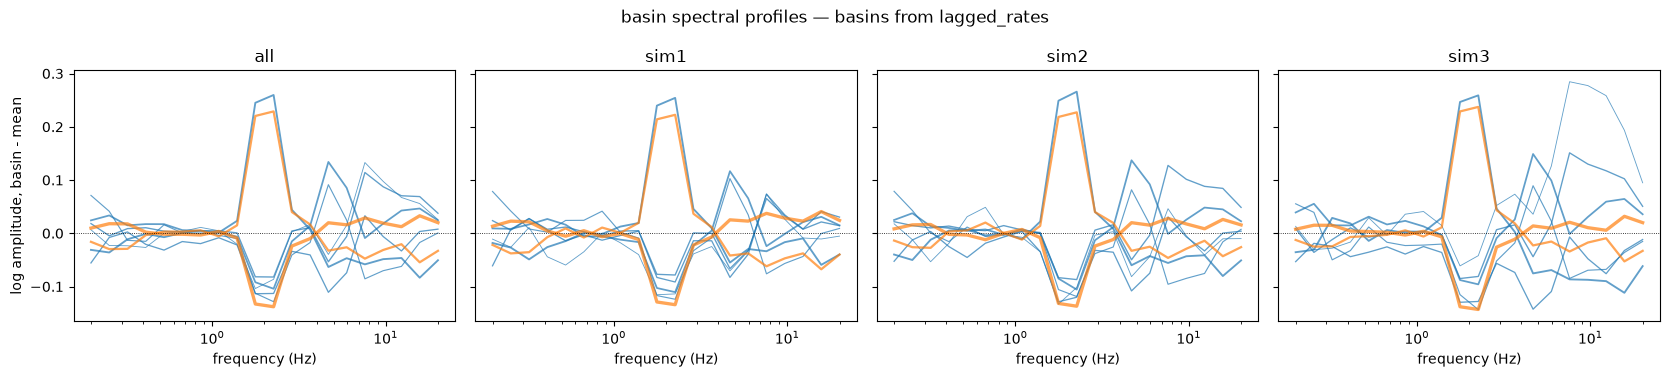

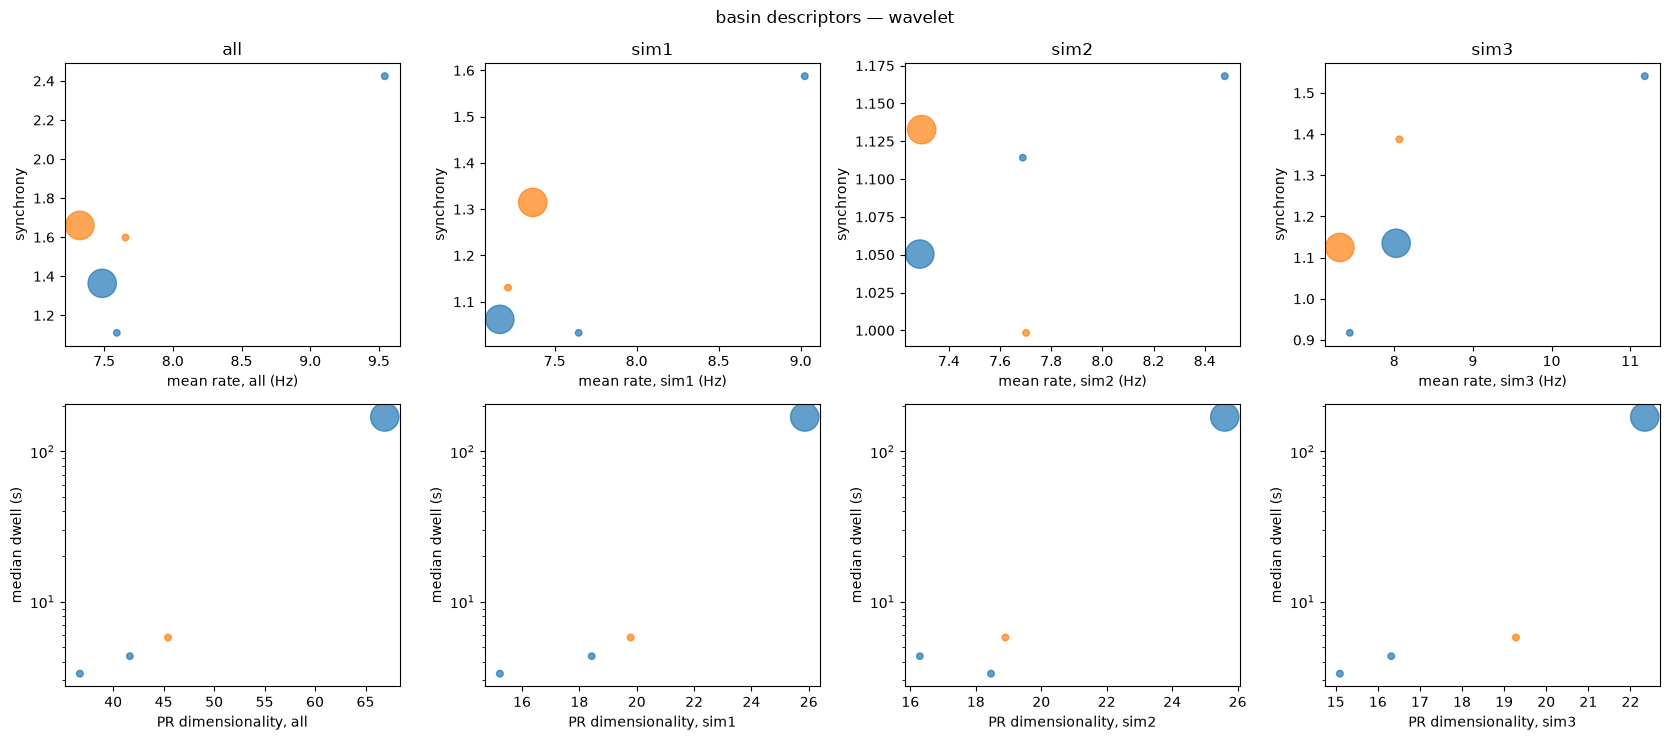

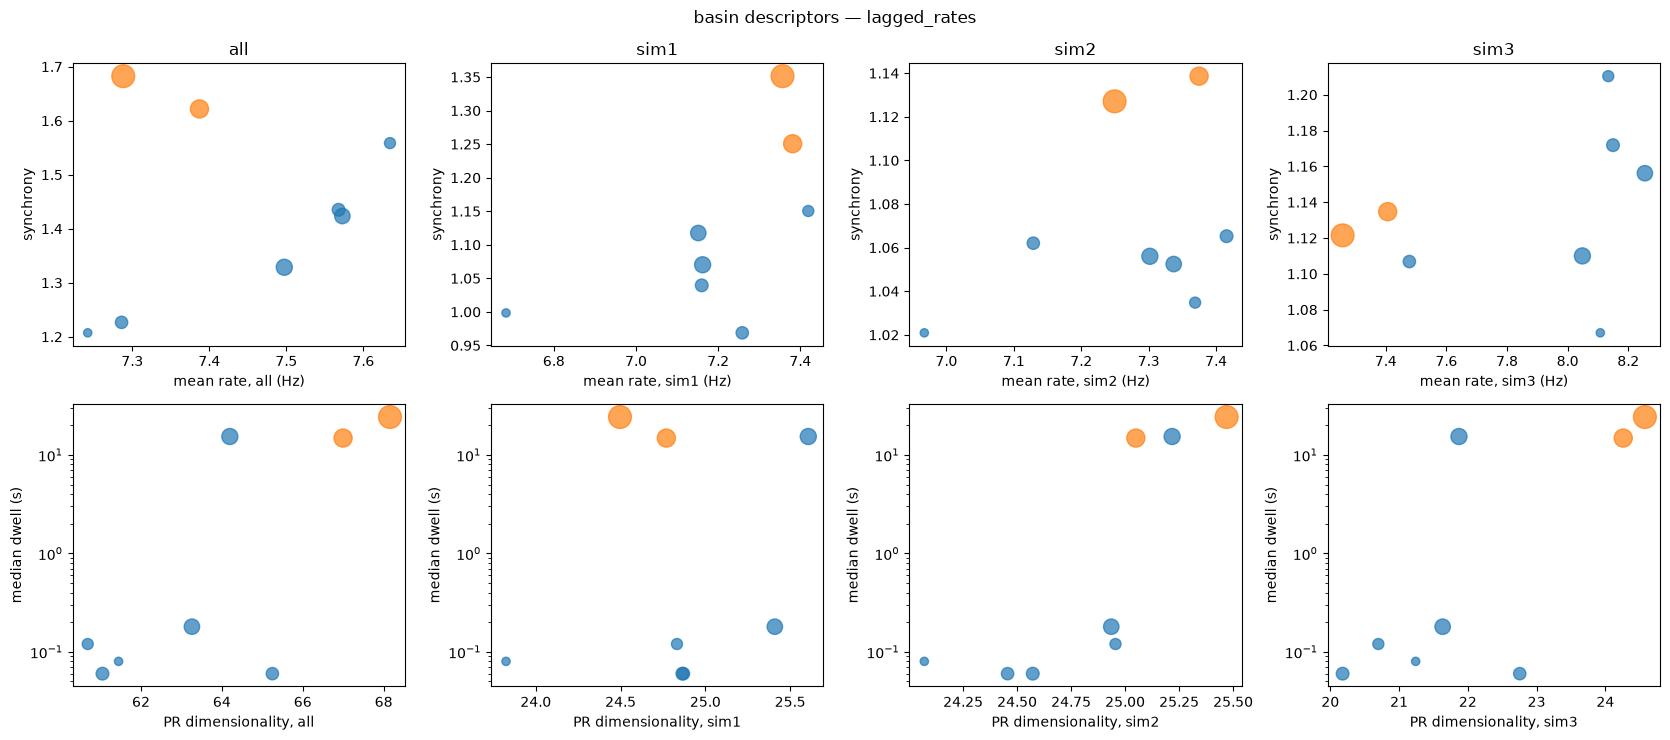

basin descriptors
subject  date representation  basin  occupancy  n_residences  dwell_median_s  dwell_mean_s  stay_prob_tau  crispness  rate_hz_all  synchrony_all  pr_dim_all  rate_hz_sim1  synchrony_sim1  pr_dim_sim1  rate_hz_sim2  synchrony_sim2  pr_dim_sim2  rate_hz_sim3  synchrony_sim3  pr_dim_sim3
    sim sim00        wavelet      0      0.005             1            4.34         4.340          0.770      0.826        7.592          1.110      41.650         7.646           1.033       18.430         7.689           1.114       16.291         7.435           0.917       16.319
    sim sim00        wavelet      1      0.008             2            3.32         3.320          0.699      0.711        9.543          2.424      36.698         9.025           1.587       15.227         8.478           1.168       18.465        11.185           1.541       15.099
    sim sim00        wavelet      2      0.988             2          169.58       169.580          0.997      0.919        

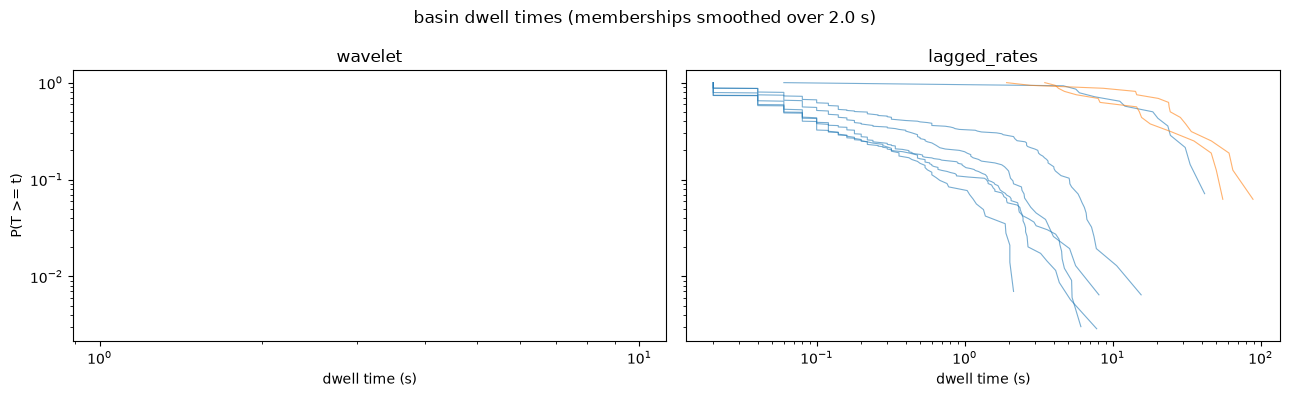

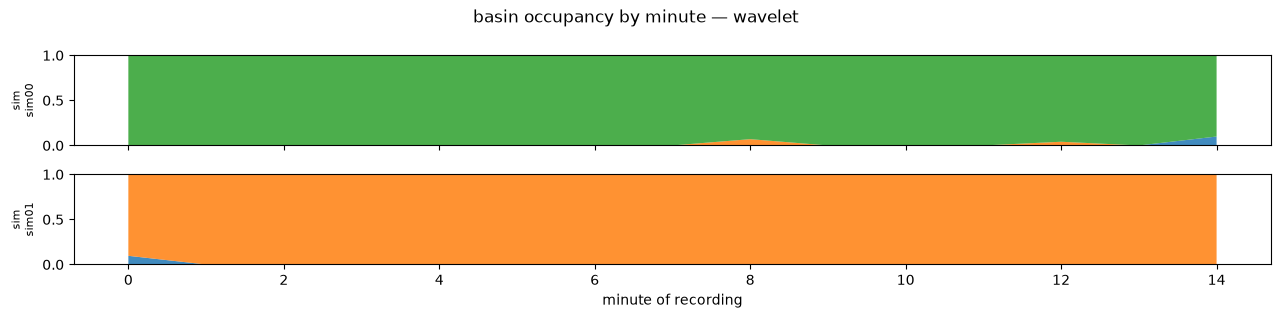

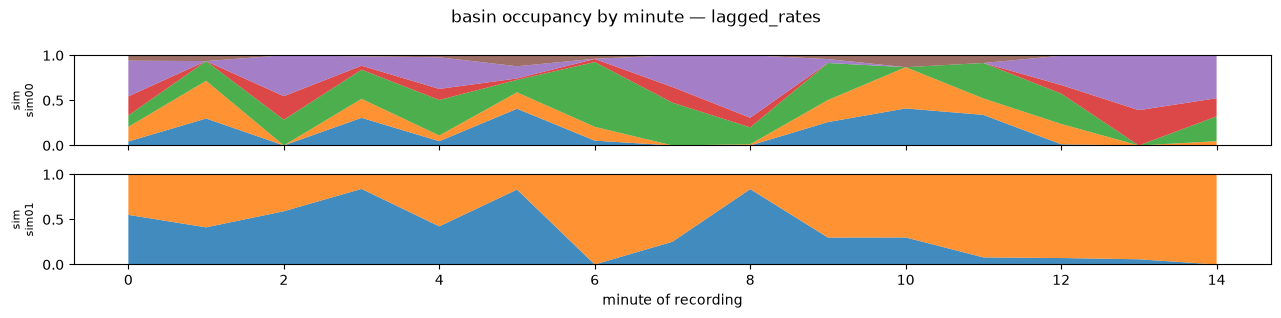

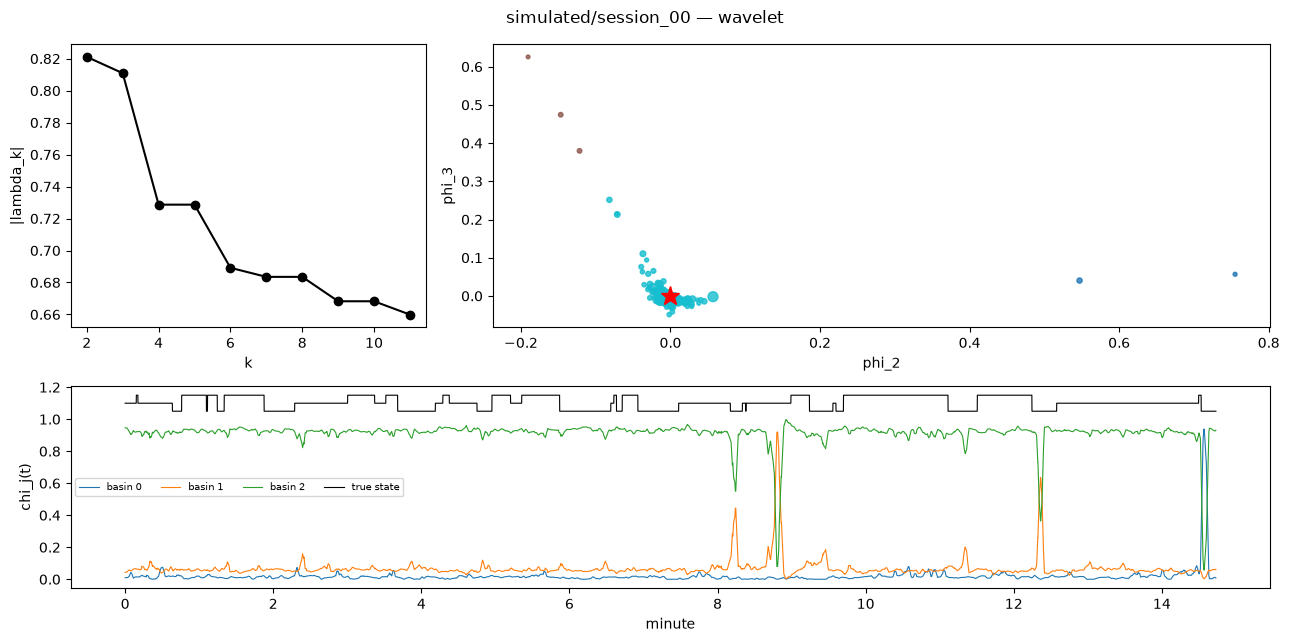

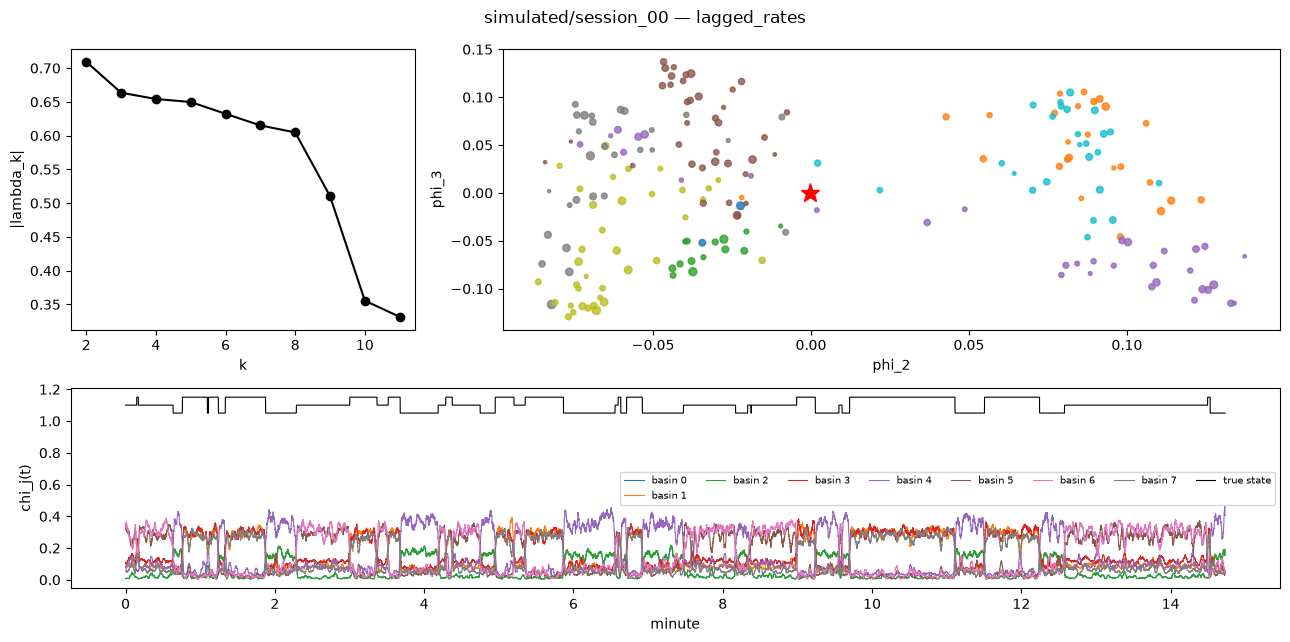

In [1]:
"""Metastable population states from a multi-timescale transfer operator.

Follows Kaur, Jain & Berman (2026), "Using timescale as a state coordinate
reveals the metastable geometry of behavior", applied to binned spike data
from every recording in the dandiset. Loaders, scaling, caching and the
simulated-data mode are carried over from the neural-manifold sweep.

Pipeline, per recording and representation:

    rates            binned counts / bin width, then RATE_TRANSFORM
    wavelets         Morlet amplitude of each unit at each of N_FREQS
                     frequencies (omega0 = W0), log-transformed; one feature
                     per unit x frequency. Edges trimmed by the cone of
                     influence of the slowest wavelet
    PCA              on the standardized features; components kept if their
                     eigenvalue exceeds a column-shuffled noise floor
    delay embedding  D consecutive frames stacked; D by Cao's E1(d)
    microstates      k-means into N clusters; N maximizes the entropy gap
                     between the real and a shuffled label sequence
    operator         T_ij(tau) = P(s_{t+tau} = j | s_t = i), estimated from
                     counts, not symmetrized
    spectrum         eigenvalues of T over TAU_GRID_S; implied timescale
                     -tau / ln|lambda|; cycle frequency of complex modes
    basins           M = largest ratio gap |l_k| / |l_{k+1}| at TAU_S; soft
                     memberships chi by G-PCCA (pygpcca), inner-simplex
                     fallback otherwise
    diagnostics      participation ratio of eigenvectors 2-4; held-out
                     predictive information of the lumped basin model against
                     a memoryless null, contiguous-block CV with everything
                     refit on training blocks

Two representations are run on each recording:

    "wavelet"        the pipeline above
    "lagged_rates"   PCA of the transformed rates without the wavelet
                     transform, then the same steps. The paper's
                     fixed-timescale operator

Basins are described by quantities with the same meaning in every recording,
so they can be compared and pooled across recordings even though the
embedding coordinates cannot (each recording has different units):

    occupancy, dwell times, lumped transition probabilities, membership
    crispness; per region: mean rate, population synchrony, participation-
    ratio dimensionality, and the wavelet spectral profile (log amplitude by
    frequency relative to the recording mean)

CELL 1  config, loaders, the sweep. Leaves `diag`, `spectra`, `timescales`,
        `predinfo`, `basins`, `profiles`, `transitions`, `dwells`, `occupancy`,
        `examples`
CELL 2  eigenvalue spectra at the working lag, and the selected M
CELL 3  implied timescales against lag
CELL 4  participation ratios and held-out predictive information
CELL 5  basin spectral profiles by region
CELL 6  basin descriptors across recordings, and dwell-time distributions
CELL 7  basin occupancy by minute
CELL 8  one recording: eigenvector geometry and memberships over time
"""

import gc
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# CONFIG — everything sweepable lives here
# =============================================================================

DOWNLOAD_DIR = Path("/storage/dandi_downloads").resolve()

# One .pkl of result frames per recording, named for bin size and transform,
# so a killed sweep resumes where it stopped. Summary CSVs are written at the
# end of cell 1.
CACHE_DIR = Path("/storage/wavelet_states")
USE_CACHE = True
SAVE_CACHE = True
SAVE_RESULTS = True

# "simulated" generates populations with SIM_STATES hidden states that differ
# only in rhythm (same mean rates). The wavelet representation should recover
# SIM_STATES basins with a high ARI against the true states.
DATA_SOURCE = "simulated"              # "nwb" | "simulated"
SIM_RECORDINGS = 2
SIM_UNITS = 80
SIM_DURATION_S = 900.0
SIM_STATES = 3
SIM_STATE_FREQS_HZ = (2.0, 5.0, 8.0)
SIM_DWELL_S = 20.0
SIM_OSC_GAIN = 0.8
SIM_LATENT_DIM = 3
SIM_SMOOTH_S = 0.5
SIM_GAIN = 0.4
SIM_BASE_RATE_HZ = 5.0
SIM_REGIONS = 3

RECORDINGS = None                 # None = all; or substrings e.g. ["sub-M05"]
MAX_RECORDINGS = None
EPOCH = "maze"                    # "maze" | "full"

BIN_S = 0.020                     # Nyquist = 1 / (2 BIN_S) = 25 Hz at 20 ms
RATE_TRANSFORM = "sqrt"           # "zscore" | "sqrt" | "none"
MIN_RATE_HZ = 0.0

# --- wavelets -----------------------------------------------------------------
W0 = 5.0                          # Morlet omega0 (paper value)
N_FREQS = 20
F_MIN_HZ = 0.2
F_MAX_FRAC_NYQUIST = 0.8
LOG_AMPLITUDE = True
EDGE_TRIM_SD = 2.0                # envelope SDs of the slowest wavelet trimmed per end

# --- PCA ------------------------------------------------------------------------
PCA_FIT_MAX_ROWS = 50_000
N_SHUFFLES = 5
MAX_PCS = 40

# --- delay embedding ------------------------------------------------------------
D_METHOD = "cao"                  # "cao" | "fixed"
D_FIXED = 10
D_MAX = 20
CAO_THRESHOLD = 0.95
CAO_SAMPLES = 2000
THEILER_S = 0.5

# --- microstates ----------------------------------------------------------------
N_GRID = (100, 200, 400, 800)
KMEANS_FIT_MAX_ROWS = 100_000
KMEANS_SEED = 0

# --- operator and basins --------------------------------------------------------
TAU_S = 1.0
TAU_GRID_S = (0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0)
N_EIG_REPORT = 10
M_MAX = 8
PSEUDOCOUNT = 1e-3
CV_FOLDS = 5
DWELL_SMOOTH_S = 2.0              # moving average on chi(t) before argmax

REPRESENTATIONS = ("wavelet", "lagged_rates")
REP_COLORS = {"wavelet": "#1f77b4", "lagged_rates": "#d62728"}

MINUTE_S = 60.0
EXAMPLE_FILE = None
EXAMPLE_MINUTES = 20


# =============================================================================
# STEP 1 — the recordings (carried over)
# =============================================================================


def recording_table(root, patterns=RECORDINGS, limit=MAX_RECORDINGS):
    rows = []
    for path in sorted(Path(root).rglob("*.nwb")):
        if patterns and not any(p in str(path) for p in patterns):
            continue
        stem = path.stem
        subject = re.search(r"sub-([^_]+)", stem)
        session = re.search(r"ses-([^_]+)", stem)
        ses = session.group(1) if session else "unknown"
        rows.append({
            "subject": subject.group(1) if subject else path.parent.name,
            "session": ses,
            "date": f"{ses[:4]}-{ses[4:6]}-{ses[6:8]}" if len(ses) >= 8 else ses,
            "has_behavior": "behavior" in stem,
            "file": str(path.relative_to(root)),
        })
    table = pd.DataFrame(rows).sort_values(["subject", "session"]).reset_index(drop=True)
    return table.head(limit) if limit else table


def unit_regions(spike_group):
    meta = getattr(spike_group, "metadata", None)
    if isinstance(meta, pd.DataFrame) and "cell_area" in meta.columns:
        return meta["cell_area"].astype(str).values
    try:
        return np.asarray(spike_group.get_info("cell_area")).astype(str)
    except Exception:
        return np.array(["all"] * len(spike_group.index))


def load_session(row, bin_size_s):
    """Binned rates (bins x units), bin centres, regions, info."""
    import pynapple as nap
    nwb = nap.load_file(str((DOWNLOAD_DIR / row["file"]).resolve()))
    spikes_all = nwb["units"]
    epoch, epoch_kind = None, "full"
    if EPOCH == "maze":
        try:
            position = nwb["Position"]
            epoch = nap.IntervalSet(start=float(position.index[0]),
                                    end=float(position.index[-1]))
            epoch_kind = "maze"
        except Exception:
            epoch = None
    if epoch is None:
        starts = [spikes_all[u].index[0] for u in spikes_all.index if len(spikes_all[u])]
        ends = [spikes_all[u].index[-1] for u in spikes_all.index if len(spikes_all[u])]
        epoch = nap.IntervalSet(start=float(min(starts)), end=float(max(ends)))
    spikes = spikes_all.restrict(epoch)
    t0, t1 = float(epoch.start[0]), float(epoch.end[0])
    edges = np.arange(t0, t1, bin_size_s)
    counts = np.empty((len(edges) - 1, len(spikes.index)), dtype=np.float32)
    for j, u in enumerate(spikes.index):
        st = np.sort(np.asarray(spikes[u].index.values, dtype=np.float64))
        counts[:, j] = np.diff(np.searchsorted(st, edges))
    rates = counts / bin_size_s
    keep = rates.mean(axis=0) > MIN_RATE_HZ
    info = {"epoch_kind": epoch_kind, "duration_s": t1 - t0,
            "n_units": int(keep.sum()), "truth": None}
    regions = unit_regions(spikes_all)[keep]
    del spikes, spikes_all, counts, nwb
    gc.collect()
    return rates[:, keep], edges[:-1] + bin_size_s / 2, regions, info


def simulate_session(row, bin_size_s):
    """Poisson population with SIM_STATES hidden rhythm states."""
    rng = np.random.default_rng(int(row["seed"]))
    n = int(SIM_DURATION_S / bin_size_s)
    p_leave = bin_size_s / SIM_DWELL_S
    h = np.zeros(n, dtype=int)
    for t in range(1, n):
        h[t] = h[t - 1]
        if rng.random() < p_leave:
            h[t] = rng.choice([s for s in range(SIM_STATES) if s != h[t - 1]])
    latent = gaussian_filter1d(rng.normal(size=(n, SIM_LATENT_DIM)),
                               sigma=SIM_SMOOTH_S / bin_size_s, axis=0, mode="wrap")
    latent /= latent.std(axis=0) + 1e-9
    log_rate = SIM_GAIN * latent @ rng.normal(size=(SIM_LATENT_DIM, SIM_UNITS))
    t_s = np.arange(n) * bin_size_s
    phases = rng.uniform(0, 2 * np.pi, size=(SIM_STATES, SIM_UNITS))
    for s, f in enumerate(SIM_STATE_FREQS_HZ[:SIM_STATES]):
        on = h == s
        log_rate[on] += SIM_OSC_GAIN * np.sin(2 * np.pi * f * t_s[on, None] + phases[s])
    rates = (rng.poisson(SIM_BASE_RATE_HZ * np.exp(log_rate) * bin_size_s)
             .astype(np.float32) / bin_size_s)
    regions = np.array([f"sim{1 + i % SIM_REGIONS}" for i in range(SIM_UNITS)])
    info = {"epoch_kind": "simulated", "duration_s": SIM_DURATION_S,
            "n_units": SIM_UNITS, "truth": h}
    return rates, t_s, regions, info


def get_session(row, bin_size_s):
    if DATA_SOURCE == "simulated":
        return simulate_session(row, bin_size_s)
    return load_session(row, bin_size_s)


def transform_rates(rates, how=RATE_TRANSFORM):
    if how == "none":
        return rates.astype(np.float32)
    if how == "sqrt":
        return np.sqrt(rates).astype(np.float32)
    if how == "zscore":
        mu, sd = rates.mean(0, keepdims=True), rates.std(0, keepdims=True)
        return np.divide(rates - mu, sd, out=np.zeros_like(rates, dtype=np.float32),
                         where=sd > 1e-12)
    raise ValueError(f"unknown RATE_TRANSFORM: {how}")


def region_groups(regions):
    groups = {"all": np.ones(len(regions), dtype=bool)}
    for region in sorted(set(regions)):
        if region != "all":
            groups[region] = regions == region
    return groups


def hms(seconds):
    seconds = int(round(seconds))
    if seconds < 3600:
        return f"{seconds // 60:d}:{seconds % 60:02d}"
    return f"{seconds // 3600:d}:{(seconds % 3600) // 60:02d}:{seconds % 60:02d}"


# =============================================================================
# STEP 2 — representations
# =============================================================================


def frequencies(bin_size_s):
    return np.geomspace(F_MIN_HZ, F_MAX_FRAC_NYQUIST / (2 * bin_size_s), N_FREQS)


def morlet_scale(f):
    return (W0 + np.sqrt(2 + W0 ** 2)) / (4 * np.pi * f)


def wavelet_features(X, freqs, fs):
    """Morlet amplitudes (bins x units*freqs), unit-major columns, float32.

    Each unit is mean-subtracted first. The wavelet is near zero-mean, so the
    amplitudes describe fluctuations around each unit's level, not the level.
    """
    n, u = X.shape
    omega = 2 * np.pi * np.fft.fftfreq(n, 1 / fs)
    filters = []
    for f in freqs:
        filt = 2 * np.exp(-0.5 * (omega * morlet_scale(f) - W0) ** 2)
        filt[omega < 0] = 0
        filters.append(filt.astype(np.complex64))
    out = np.empty((n, u * len(freqs)), dtype=np.float32)
    for j in range(u):
        spec = np.fft.fft(X[:, j] - X[:, j].mean()).astype(np.complex64)
        for i, filt in enumerate(filters):
            out[:, j * len(freqs) + i] = np.abs(np.fft.ifft(spec * filt))
    if LOG_AMPLITUDE:
        np.log(out + 1e-6, out=out)
    return out


def pca_above_floor(F, rng):
    """PCA on evenly spaced rows of standardized F. Keeps components above
    the mean leading eigenvalue of column-shuffled surrogates."""
    rows = np.unique(np.linspace(0, len(F) - 1, min(PCA_FIT_MAX_ROWS, len(F))).astype(int))
    sub = F[rows]
    n_comp = min(MAX_PCS, sub.shape[1], sub.shape[0] - 1)
    pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=0).fit(sub)
    floors = []
    for _ in range(N_SHUFFLES):
        shuffled = np.column_stack([rng.permutation(c) for c in sub.T])
        floors.append(PCA(n_components=1, svd_solver="randomized",
                          random_state=0).fit(shuffled).explained_variance_[0])
    k = max(2, int((pca.explained_variance_ > np.mean(floors)).sum()))
    return pca, k


def project(F, pca, k, mu, sd, chunk=100_000):
    Z = np.empty((len(F), k), dtype=np.float32)
    for a in range(0, len(F), chunk):
        Z[a:a + chunk] = ((F[a:a + chunk] - mu) / sd - pca.mean_) @ pca.components_[:k].T
    return Z


def delay_embed(Z, d):
    n = len(Z) - d + 1
    return np.hstack([Z[i:i + n] for i in range(d)])


def cao_dimension(Z, fs, rng):
    """Smallest d with Cao's E1(d) >= CAO_THRESHOLD (max-norm, Theiler window,
    subsampled queries), or D_FIXED. Returns (d, E1 values computed)."""
    if D_METHOD == "fixed":
        return D_FIXED, np.array([])
    theiler = int(THEILER_S * fs)
    n_all = len(Z) - D_MAX - 1
    q = np.sort(rng.choice(n_all, min(CAO_SAMPLES, n_all), replace=False))

    def E(d):
        Yd = np.hstack([Z[q + i] for i in range(d)])
        dist, idx = NearestNeighbors(n_neighbors=10, metric="chebyshev").fit(Yd).kneighbors(Yd)
        far = np.abs(q[idx] - q[:, None]) > theiler
        far[:, 0] = False
        col = far.argmax(1)
        rows = np.arange(len(q))
        has = far.any(1) & (dist[rows, col] > 0)
        j = idx[rows, col][has]
        d_next = np.maximum(np.max(np.abs(Yd[has] - Yd[j]), axis=1),
                            np.max(np.abs(Z[q[has] + d] - Z[q[j] + d]), axis=1))
        return float(np.mean(d_next / dist[rows, col][has]))

    e_prev, E1 = E(1), []
    for d in range(1, D_MAX + 1):
        e_next = E(d + 1)
        E1.append(e_next / e_prev)
        if E1[-1] >= CAO_THRESHOLD:
            return d, np.array(E1)
        e_prev = e_next
    return D_MAX, np.array(E1)


# =============================================================================
# STEP 3 — microstates, operator, basins
# =============================================================================


def cluster(Y, n_clusters):
    rows = np.unique(np.linspace(0, len(Y) - 1, min(KMEANS_FIT_MAX_ROWS, len(Y))).astype(int))
    km = MiniBatchKMeans(n_clusters=n_clusters, batch_size=8192, n_init=3,
                         random_state=KMEANS_SEED).fit(Y[rows])
    return km, km.predict(Y)


def count_matrix(labels, n, lag, segment=None):
    """Transition counts at `lag`, only between bins in the same segment."""
    a, b = labels[:-lag], labels[lag:]
    if segment is not None:
        same = segment[:-lag] == segment[lag:]
        a, b = a[same], b[same]
    C = np.zeros((n, n))
    np.add.at(C, (a, b), 1)
    return C


def row_stochastic(C):
    r = C.sum(1, keepdims=True)
    r[r == 0] = 1
    return C / r


def entropy_rate(labels, n):
    T = row_stochastic(count_matrix(labels, n, 1))
    pi = np.bincount(labels, minlength=n) / len(labels)
    return float(-(pi[:, None] * T * np.log(np.where(T > 0, T, 1))).sum())


def select_n(Y, rng):
    gaps = {}
    for n in N_GRID:
        _, lab = cluster(Y, n)
        gaps[n] = entropy_rate(rng.permutation(lab), n) - entropy_rate(lab, n)
    return max(gaps, key=gaps.get), gaps


def spectrum(T, k):
    evals, evecs = np.linalg.eig(T)
    order = np.argsort(-np.abs(evals))
    return evals[order][:k], evecs[:, order][:, :k]


def participation_ratio(v):
    v = np.real(v)
    return float((v ** 2).sum() ** 2 / (v ** 4).sum())


def inner_simplex(Phi):
    X = Phi[:, 1:].copy()
    X -= X.mean(0)
    v = [int(np.argmax(np.linalg.norm(X, axis=1)))]
    for _ in range(Phi.shape[1] - 1):
        X = X - X[v[-1]]
        if len(v) > 1:
            Q, _ = np.linalg.qr(X[v[1:]].T)
            X = X - X @ Q @ Q.T
        v.append(int(np.argmax(np.linalg.norm(X, axis=1))))
    return v[:Phi.shape[1]]


def memberships(T, m):
    """Soft memberships (states x m) or (None, reason). G-PCCA refuses an m
    that splits a complex-conjugate pair; that case returns None. Without
    pygpcca, inner simplex on real eigenvector parts (assumes near-reversibility)."""
    try:
        from pygpcca import GPCCA
    except ImportError:
        GPCCA = None
    if GPCCA is not None:
        try:
            g = GPCCA(T, z="LM", method="brandts")
            g.optimize(m)
            return g.memberships, "gpcca"
        except ValueError as exc:
            return None, f"gpcca: {exc}"
    _, V = spectrum(T, m)
    Phi = np.real(V)
    Phi[:, 0] = 1.0
    chi = np.clip(Phi @ np.linalg.pinv(Phi[inner_simplex(Phi)]), 0, None)
    return chi / (chi.sum(1, keepdims=True) + 1e-12), "inner_simplex"


def memberships_on_visited(C, m):
    """Memberships on states with transitions in and out; others uniform."""
    ok = (C.sum(1) > 0) & (C.sum(0) > 0)
    chi_sub, how = memberships(row_stochastic(C[np.ix_(ok, ok)]), m)
    if chi_sub is None:
        return None, how
    chi = np.full((len(C), m), 1.0 / m)
    chi[ok] = chi_sub
    return chi, how


def heldout_bits(train_lab, train_seg, test_lab, test_seg, n, lag, T=None):
    """Mean log2 P(s_{t+lag} | s_t) - log2 P(s_{t+lag}) over held-out transitions."""
    if T is None:
        T = row_stochastic(count_matrix(train_lab, n, lag, train_seg) + PSEUDOCOUNT)
    pi = np.bincount(train_lab, minlength=n) + PSEUDOCOUNT
    pi = pi / pi.sum()
    a, b = test_lab[:-lag], test_lab[lag:]
    same = test_seg[:-lag] == test_seg[lag:]
    if same.sum() == 0:
        return np.nan
    return float(np.mean(np.log2(T[a[same], b[same]]) - np.log2(pi[b[same]])))


def cross_validate(F_raw, d, fs, n_clusters):
    """Contiguous-block CV. Standardization, PCA, clustering and the operator
    are refit on training blocks. Delay vectors spanning a block boundary are
    dropped; transitions are not counted across removed blocks."""
    lag = max(1, int(round(TAU_S * fs)))
    block = np.arange(len(F_raw)) * CV_FOLDS // len(F_raw)
    rows = []
    for fold in range(CV_FOLDS):
        train_mask = block != fold
        tr = np.flatnonzero(train_mask)
        mu, sd = F_raw[tr].mean(0), F_raw[tr].std(0)
        sd[sd < 1e-12] = 1
        pca, k = pca_above_floor((F_raw[tr] - mu) / sd, np.random.default_rng(fold))
        Y = delay_embed(project(F_raw, pca, k, mu, sd), d)
        win = np.lib.stride_tricks.sliding_window_view(train_mask, d)
        ok_tr, ok_te = win.all(1), (~win).all(1)
        seg = np.cumsum(np.r_[0, np.diff(train_mask.astype(int)) != 0])[:len(Y)]
        km, lab_tr = cluster(Y[ok_tr], n_clusters)
        lab_te = km.predict(Y[ok_te])
        seg_tr, seg_te = seg[ok_tr], seg[ok_te]
        C = count_matrix(lab_tr, n_clusters, lag, seg_tr)
        rows.append({"fold": fold, "model": "microstates", "m": n_clusters,
                     "bits": heldout_bits(lab_tr, seg_tr, lab_te, seg_te, n_clusters,
                                          lag, row_stochastic(C + PSEUDOCOUNT))})
        for m in range(2, M_MAX + 1):
            chi, _ = memberships_on_visited(C, m)
            bits = np.nan
            if chi is not None:
                bits = heldout_bits(chi[lab_tr].argmax(1), seg_tr,
                                    chi[lab_te].argmax(1), seg_te, m, lag)
            rows.append({"fold": fold, "model": "basins", "m": m, "bits": bits})
        del Y
        gc.collect()
    return rows


# =============================================================================
# STEP 4 — basin descriptors
# =============================================================================


def dwell_runs(hard, fs):
    """Residences of the dominant basin; runs touching either end dropped."""
    change = np.flatnonzero(np.diff(hard)) + 1
    starts, ends = np.r_[0, change], np.r_[change, len(hard)]
    return [(int(hard[s]), (e - s) / fs) for s, e in zip(starts[1:-1], ends[1:-1])]


def synchrony(counts):
    """var(sum over units) / sum(var of units): 1 for independent units."""
    denom = counts.var(0).sum()
    return float(counts.sum(1).var() / denom) if denom > 0 else np.nan


def pr_dimension(X):
    """Participation ratio of the covariance eigenvalues."""
    if X.shape[0] < 3 or X.shape[1] < 2:
        return np.nan
    ev = np.clip(np.linalg.eigvalsh(np.cov(X, rowvar=False)), 0, None)
    return float(ev.sum() ** 2 / (ev ** 2).sum()) if ev.sum() > 0 else np.nan


def describe_basins(hard, chi_t, rates, Xt, feats, regions, freqs, fs, m, lag, tag):
    """One row per basin (and per basin x region), plus spectral profiles and
    the lumped transition matrix. `rates` in Hz, `Xt` transformed, `feats` the
    unstandardized log wavelet amplitudes, all aligned to `hard`."""
    basin_rows, profile_rows, trans_rows = [], [], []
    groups = region_groups(regions)
    nf = len(freqs)
    base = feats.mean(0)
    Cb = count_matrix(hard, m, lag)
    Tb = row_stochastic(Cb)
    runs = dwell_runs(hard, fs)
    for b in range(m):
        sel = hard == b
        dw = np.array([s for bb, s in runs if bb == b])
        row = {**tag, "basin": b, "occupancy": float(sel.mean()),
               "n_residences": len(dw),
               "dwell_median_s": float(np.median(dw)) if len(dw) else np.nan,
               "dwell_mean_s": float(dw.mean()) if len(dw) else np.nan,
               "stay_prob_tau": float(Tb[b, b]),
               "crispness": float(chi_t[sel, b].mean()) if sel.any() else np.nan}
        if sel.sum() > 10:
            counts = rates[sel] / fs
            for g, mask in groups.items():
                row[f"rate_hz_{g}"] = float(rates[sel][:, mask].mean())
                row[f"synchrony_{g}"] = synchrony(counts[:, mask])
                row[f"pr_dim_{g}"] = pr_dimension(Xt[sel][:, mask])
            dev = (feats[sel].mean(0) - base).reshape(-1, nf)
            for g, mask in groups.items():
                profile_rows += [{**tag, "basin": b, "region": g, "freq_hz": f,
                                  "occupancy": float(sel.mean()), "deviation": float(v)}
                                 for f, v in zip(freqs, dev[mask].mean(0))]
        basin_rows.append(row)
        trans_rows += [{**tag, "from": b, "to": c, "p": float(Tb[b, c])} for c in range(m)]
    return basin_rows, profile_rows, trans_rows, runs


# =============================================================================
# STEP 5 — the sweep
# =============================================================================

if DATA_SOURCE == "simulated":
    recordings = pd.DataFrame([{
        "subject": "sim", "session": f"{i:02d}", "date": f"sim{i:02d}",
        "has_behavior": False, "seed": i,
        "file": f"simulated/session_{i:02d}"} for i in range(SIM_RECORDINGS)])
    print(f"SIMULATED data: {SIM_RECORDINGS} sessions, {SIM_STATES} hidden states "
          f"at {SIM_STATE_FREQS_HZ[:SIM_STATES]} Hz, dwell {SIM_DWELL_S:.0f} s")
else:
    recordings = recording_table(DOWNLOAD_DIR)
    print(f"{len(recordings)} recordings")
print(recordings[["subject", "date", "file"]].to_string(index=False))
freqs = frequencies(BIN_S)
print(f"\nbin {BIN_S * 1e3:.0f} ms | transform {RATE_TRANSFORM} | "
      f"{N_FREQS} freqs {freqs[0]:.2f}-{freqs[-1]:.1f} Hz | tau {TAU_S} s | "
      f"{CV_FOLDS}-fold contiguous CV | representations: {', '.join(REPRESENTATIONS)}")
if USE_CACHE or SAVE_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

FRAME_NAMES = ("diag", "spectra", "timescales", "predinfo", "basins", "profiles",
               "transitions", "dwells", "occupancy")
frames = {k: [] for k in FRAME_NAMES}
examples, skipped = {}, []
example_file = (recordings["file"].iloc[0] if EXAMPLE_FILE is None else
                next((f for f in recordings["file"] if EXAMPLE_FILE in f),
                     recordings["file"].iloc[0]))
sweep_started = time.perf_counter()

for rec_i, (_, rec) in enumerate(recordings.iterrows(), start=1):
    is_example = rec["file"] == example_file
    cache = CACHE_DIR / f"{Path(rec['file']).stem}__{BIN_S * 1e3:.0f}ms__{RATE_TRANSFORM}.pkl"
    if USE_CACHE and cache.exists():
        stored = pd.read_pickle(cache)
        for k in FRAME_NAMES:
            frames[k].append(stored[k])
        if is_example:
            examples = stored.get("examples", {})
        print(f"[{rec_i}/{len(recordings)}] {rec['file']}: from cache")
        continue

    t_load = time.perf_counter()
    try:
        rates, centers, regions, info = get_session(rec, BIN_S)
    except Exception as exc:
        print(f"\n{rec['file']}: could not load ({type(exc).__name__}: {exc})")
        skipped.append({"file": rec["file"], "reason": str(exc)})
        continue
    fs = 1 / BIN_S
    lag = max(1, int(round(TAU_S * fs)))
    trim = int(EDGE_TRIM_SD * morlet_scale(freqs[0]) * fs)
    keep = slice(trim, len(rates) - trim)
    X = transform_rates(rates)
    feats_all = wavelet_features(X, freqs, fs)[keep]      # used by both representations
    rates, X = rates[keep], X[keep]
    truth = info["truth"][keep] if info["truth"] is not None else None
    ident = {"file": rec["file"], "subject": rec["subject"], "date": rec["date"]}
    done = time.perf_counter() - sweep_started
    eta = (done / max(rec_i - 1, 1)) * (len(recordings) - rec_i + 1)
    print(f"\n[{rec_i}/{len(recordings)}] {rec['subject']} {rec['date']} | "
          f"elapsed {hms(done)}" + (f", ~{hms(eta)} left" if rec_i > 1 else ""))
    print(f"    {info['epoch_kind']} epoch {info['duration_s'] / 60:.1f} min | "
          f"{X.shape[1]} units | {len(X)} bins after trimming {trim / fs:.1f} s per end "
          f"| loaded in {time.perf_counter() - t_load:.1f}s")

    out = {k: [] for k in FRAME_NAMES}
    for rep in REPRESENTATIONS:
        t_rep = time.perf_counter()
        rng = np.random.default_rng(0)
        tag = {**ident, "representation": rep}
        F_raw = feats_all if rep == "wavelet" else X
        mu, sd = F_raw.mean(0), F_raw.std(0)
        sd[sd < 1e-12] = 1
        pca, n_pc = pca_above_floor((F_raw - mu) / sd, rng)
        Z = project(F_raw, pca, n_pc, mu, sd)
        d, E1 = cao_dimension(Z, fs, rng)
        Y = delay_embed(Z, d)
        del Z
        n_clusters, gaps = select_n(Y, rng)
        km, lab = cluster(Y, n_clusters)
        del Y
        gc.collect()

        # --- operator at the working lag, basins --------------------------------
        C = count_matrix(lab, n_clusters, lag)
        evals, evecs = spectrum(row_stochastic(C), N_EIG_REPORT + 1)
        mags = np.abs(evals)
        m_sel = int(np.argmax(mags[1:M_MAX] / mags[2:M_MAX + 1])) + 2
        chi, how = memberships_on_visited(C, m_sel)
        if chi is None:                    # m splits a complex pair: take m + 1
            m_sel += 1
            chi, how = memberships_on_visited(C, m_sel)
            how += " (m+1)"
        chi_t = chi[lab]
        hard = uniform_filter1d(chi_t, size=max(1, int(DWELL_SMOOTH_S * fs)),
                                axis=0).argmax(1)
        pi = np.bincount(lab, minlength=n_clusters) / len(lab)

        # --- implied timescales over the lag grid --------------------------------
        for tau_s in TAU_GRID_S:
            L = max(1, int(round(tau_s * fs)))
            ev, _ = spectrum(row_stochastic(count_matrix(lab, n_clusters, L)), 4)
            for k in range(1, 4):
                mag = float(abs(ev[k]))
                out["timescales"].append({
                    **tag, "tau_s": L / fs, "mode": k + 1, "abs_lambda": mag,
                    "implied_s": -(L / fs) / np.log(mag) if 0 < mag < 1 else np.nan,
                    "cycle_hz": float(abs(np.angle(ev[k])) / (2 * np.pi * L / fs))})

        # --- descriptors, aligned to the last frame of each delay window ---------
        a = slice(d - 1, d - 1 + len(lab))
        b_rows, p_rows, t_rows, runs = describe_basins(
            hard, chi_t, rates[a], X[a], feats_all[a], regions, freqs, fs,
            m_sel, lag, tag)
        out["basins"] += b_rows
        out["profiles"] += p_rows
        out["transitions"] += t_rows
        out["dwells"] += [{**tag, "basin": bb, "dwell_s": s} for bb, s in runs]
        minute = (np.arange(len(hard)) / fs // MINUTE_S).astype(int)
        occ = pd.crosstab(minute, hard, normalize="index")
        out["occupancy"] += [{**tag, "minute": int(mi), "basin": int(bb),
                              "fraction": float(occ.loc[mi, bb])}
                             for mi in occ.index for bb in occ.columns]

        # --- diagnostics --------------------------------------------------------
        out["spectra"] += [{**tag, "k": k + 1, "abs_lambda": float(abs(v)),
                            "angle": float(np.angle(v))} for k, v in enumerate(evals)]
        prs = [participation_ratio(evecs[:, k]) for k in (1, 2, 3)]
        ari = np.nan
        if truth is not None:
            from sklearn.metrics import adjusted_rand_score
            ari = float(adjusted_rand_score(truth[a], hard))
        out["diag"].append({**tag, "n_units": X.shape[1], "n_pcs": n_pc, "d": d,
                            "n_clusters": n_clusters, "m": m_sel, "basin_method": how,
                            "abs_lambda2": float(mags[1]), "pr2": prs[0],
                            "pr3": prs[1], "pr4": prs[2], "ari_truth": ari})
        out["predinfo"] += [{**tag, **r} for r in
                            cross_validate(F_raw, d, fs, n_clusters)]
        if is_example:
            n_ex = int(EXAMPLE_MINUTES * 60 * fs)
            examples[rep] = {"file": rec["file"], "fs": fs,
                             "phi": np.real(evecs[:, 1:4]), "pi": pi,
                             "dominant": chi.argmax(1), "evals": evals,
                             "chi_t": chi_t[:n_ex].astype(np.float32),
                             "truth": None if truth is None else truth[a][:n_ex]}
        print(f"    {rep:13s} {n_pc} PCs, d={d}, N={n_clusters}, M={m_sel} ({how}), "
              f"|l2|={mags[1]:.3f}, PR2={prs[0]:.0f}"
              + (f", ARI {ari:.2f}" if truth is not None else "")
              + f" | {hms(time.perf_counter() - t_rep)}", flush=True)
        del lab, chi_t, hard
        gc.collect()

    out = {k: pd.DataFrame(v) for k, v in out.items()}
    for k in FRAME_NAMES:
        frames[k].append(out[k])
    if SAVE_CACHE:
        pd.to_pickle({**out, "examples": examples if is_example else {}}, cache)
    del rates, X, feats_all
    gc.collect()

(diag, spectra, timescales, predinfo, basins, profiles, transitions, dwells,
 occupancy) = (pd.concat(frames[k], ignore_index=True) if frames[k] else pd.DataFrame()
               for k in FRAME_NAMES)
print(f"\nsweep finished in {(time.perf_counter() - sweep_started) / 60:.1f} min")
if skipped:
    print(pd.DataFrame(skipped).to_string(index=False))
print(diag.drop(columns=["file"]).round(3).to_string(index=False))
if SAVE_RESULTS:
    for name in FRAME_NAMES:
        frame = globals()[name]
        if len(frame):
            frame.to_csv(CACHE_DIR / f"results_{name}.csv", index=False)


def jitter(n, width=0.12):
    return np.random.uniform(-width, width, n)


# %% ===========================================================================
# CELL 2 — eigenvalue spectra at the working lag, and the selected M
# ==============================================================================
# |lambda_k| of the operator at TAU_S, one line per recording. Metastable
# structure appears as a few eigenvalues near 1 followed by a drop. Right: M
# selected by the largest ratio gap.

fig, axes = plt.subplots(1, len(REPRESENTATIONS) + 1, figsize=(15, 4.2))
fig.suptitle(f"transfer-operator spectrum at tau = {TAU_S} s")
for ax, rep in zip(axes, REPRESENTATIONS):
    sub = spectra[(spectra["representation"] == rep) & (spectra["k"] > 1)]
    for _, one in sub.groupby("file"):
        ax.plot(one["k"], one["abs_lambda"], color=REP_COLORS[rep], alpha=0.4, lw=0.8)
    med = sub.groupby("k")["abs_lambda"].median()
    ax.plot(med.index, med.values, color=REP_COLORS[rep], lw=2.4)
    ax.set_title(rep); ax.set_xlabel("eigenvalue index k"); ax.set_ylabel("|lambda_k|")
ax = axes[-1]
for j, rep in enumerate(REPRESENTATIONS):
    vals = diag.loc[diag["representation"] == rep, "m"]
    ax.scatter(j + jitter(len(vals)), vals, color=REP_COLORS[rep], s=25)
ax.set_xticks(range(len(REPRESENTATIONS))); ax.set_xticklabels(REPRESENTATIONS)
ax.set_ylabel("selected M")
fig.tight_layout(); plt.show(); plt.close(fig)


# %% ===========================================================================
# CELL 3 — implied timescales against lag
# ==============================================================================
# -tau / ln|lambda| for modes 2-4, per recording. Flat in tau means the
# dynamics are Markovian in this state space; drift means residual memory.
# Complex eigenvalues at the working lag are listed with their cycle frequency.

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(13, 4.2), sharey=True,
                         squeeze=False)
fig.suptitle("implied timescales against lag")
for ax, rep in zip(axes[0], REPRESENTATIONS):
    sub = timescales[timescales["representation"] == rep]
    for (_, mode), one in sub.groupby(["file", "mode"]):
        ax.plot(one["tau_s"], one["implied_s"], color=f"C{mode - 2}", alpha=0.45, lw=0.8)
    for mode in (2, 3, 4):
        ax.plot([], [], color=f"C{mode - 2}", label=f"mode {mode}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("lag tau (s)"); ax.set_title(rep)
axes[0, 0].set_ylabel("implied timescale (s)"); axes[0, 0].legend(fontsize=8)
fig.tight_layout(); plt.show(); plt.close(fig)

osc = timescales[(timescales["cycle_hz"] > 0) &
                 np.isclose(timescales["tau_s"], TAU_S, rtol=0.05)]
if len(osc):
    print("complex eigenvalues at the working lag")
    print(osc[["subject", "date", "representation", "mode", "abs_lambda", "cycle_hz"]]
          .round(3).to_string(index=False))


# %% ===========================================================================
# CELL 4 — participation ratios and held-out predictive information
# ==============================================================================
# Left: participation ratio of eigenvectors 2-4 (near 1 = concentrated on one
# cluster, near N = spread over all). Right: held-out bits per transition of
# the lumped basin model against a memoryless null, by M, mean over folds.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
labels = []
for j, rep in enumerate(REPRESENTATIONS):
    sub = diag[diag["representation"] == rep]
    for c, col in enumerate(("pr2", "pr3", "pr4")):
        ax.scatter(3 * j + c + jitter(len(sub), 0.1), sub[col], color=REP_COLORS[rep], s=18)
        labels.append(f"{rep}\nphi{c + 2}")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
ax.set_yscale("log"); ax.set_ylabel("participation ratio")
ax = axes[1]
lumped = (predinfo[predinfo["model"] == "basins"]
          .groupby(["file", "representation", "m"], as_index=False)["bits"].mean())
for (_, rep), one in lumped.groupby(["file", "representation"]):
    ax.plot(one["m"], one["bits"], color=REP_COLORS[rep], alpha=0.4, lw=0.8)
for rep in REPRESENTATIONS:
    med = lumped[lumped["representation"] == rep].groupby("m")["bits"].median()
    ax.plot(med.index, med.values, color=REP_COLORS[rep], lw=2.4, label=rep)
ax.set_xlabel("number of basins M"); ax.set_ylabel("held-out bits / transition")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show(); plt.close(fig)


# %% ===========================================================================
# CELL 5 — basin spectral profiles, by region
# ==============================================================================
# Mean log wavelet amplitude in each basin minus the recording mean, averaged
# over the units of each region. Frequency and region are shared across
# recordings. Line width scales with basin occupancy. Basin numbers are not
# matched across recordings.

if len(profiles):
    for rep in REPRESENTATIONS:
        sub_rep = profiles[profiles["representation"] == rep]
        regs = [r for r in sorted(sub_rep["region"].unique())]
        files = sorted(sub_rep["file"].unique())
        fig, axes = plt.subplots(1, len(regs), figsize=(4.2 * len(regs), 3.8),
                                 squeeze=False, sharey=True)
        fig.suptitle(f"basin spectral profiles — basins from {rep}")
        for c, region in enumerate(regs):
            ax = axes[0, c]
            for (file, b), one in sub_rep[sub_rep["region"] == region].groupby(["file", "basin"]):
                ax.plot(one["freq_hz"], one["deviation"], color=f"C{files.index(file) % 10}",
                        alpha=0.7, lw=0.5 + 3 * one["occupancy"].iloc[0])
            ax.axhline(0, color="k", lw=0.6, ls=":")
            ax.set_xscale("log"); ax.set_title(region); ax.set_xlabel("frequency (Hz)")
        axes[0, 0].set_ylabel("log amplitude, basin - mean")
        fig.tight_layout(); plt.show(); plt.close(fig)


# %% ===========================================================================
# CELL 6 — basin descriptors across recordings, and dwell times
# ==============================================================================
# Each point is one basin of one recording, sized by occupancy. Rate, synchrony
# and participation-ratio dimensionality are per region; synchrony is
# var(summed counts) / sum(unit variances), 1 for independent units. Bottom
# row: complementary CDF of residence times per basin.

if len(basins):
    groups_all = sorted({c[len("rate_hz_"):] for c in basins.columns
                         if c.startswith("rate_hz_")})
    for rep in REPRESENTATIONS:
        sub = basins[basins["representation"] == rep]
        files = sorted(sub["file"].unique())
        colours = [f"C{files.index(f) % 10}" for f in sub["file"]]
        fig, axes = plt.subplots(2, len(groups_all), figsize=(4.2 * len(groups_all), 7.5),
                                 squeeze=False)
        fig.suptitle(f"basin descriptors — {rep}")
        for c, g in enumerate(groups_all):
            ax = axes[0, c]
            ax.scatter(sub[f"rate_hz_{g}"], sub[f"synchrony_{g}"], c=colours,
                       s=20 + 400 * sub["occupancy"], alpha=0.7)
            ax.set_xlabel(f"mean rate, {g} (Hz)"); ax.set_ylabel("synchrony")
            ax.set_title(g)
            ax = axes[1, c]
            ax.scatter(sub[f"pr_dim_{g}"], sub["dwell_median_s"], c=colours,
                       s=20 + 400 * sub["occupancy"], alpha=0.7)
            ax.set_xlabel(f"PR dimensionality, {g}"); ax.set_ylabel("median dwell (s)")
            ax.set_yscale("log")
        fig.tight_layout(); plt.show(); plt.close(fig)

    print("basin descriptors")
    print(basins.drop(columns=["file"]).round(3).to_string(index=False))

if len(dwells):
    fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(13, 4.0), sharey=True,
                             squeeze=False)
    fig.suptitle(f"basin dwell times (memberships smoothed over {DWELL_SMOOTH_S} s)")
    files = sorted(dwells["file"].unique())
    for ax, rep in zip(axes[0], REPRESENTATIONS):
        for (file, b), one in dwells[dwells["representation"] == rep].groupby(["file", "basin"]):
            x = np.sort(one["dwell_s"].values)
            if len(x) >= 5:
                ax.plot(x, 1 - np.arange(len(x)) / len(x),
                        color=f"C{files.index(file) % 10}", alpha=0.6, lw=0.8)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("dwell time (s)"); ax.set_title(rep)
    axes[0, 0].set_ylabel("P(T >= t)")
    fig.tight_layout(); plt.show(); plt.close(fig)


# %% ===========================================================================
# CELL 7 — basin occupancy by minute
# ==============================================================================
# Fraction of each minute spent in each basin, one row per recording, stacked.
# Changes across the session indicate non-stationarity in basin use.

if len(occupancy):
    for rep in REPRESENTATIONS:
        sub = occupancy[occupancy["representation"] == rep]
        files = sorted(sub["file"].unique())
        fig, axes = plt.subplots(len(files), 1, figsize=(13, 1.6 * len(files)),
                                 squeeze=False, sharex=True)
        fig.suptitle(f"basin occupancy by minute — {rep}")
        for r, file in enumerate(files):
            grid = sub[sub["file"] == file].pivot_table(index="minute", columns="basin",
                                                         values="fraction", fill_value=0)
            axes[r, 0].stackplot(grid.index, grid.values.T, alpha=0.85)
            one = sub[sub["file"] == file].iloc[0]
            axes[r, 0].set_ylabel(f"{one['subject']}\n{one['date']}", fontsize=8)
            axes[r, 0].set_ylim(0, 1)
        axes[-1, 0].set_xlabel("minute of recording")
        fig.tight_layout(); plt.show(); plt.close(fig)


# %% ===========================================================================
# CELL 8 — one recording: eigenvector geometry and memberships
# ==============================================================================
# Clusters at (phi_2, phi_3), sized by stationary occupancy, coloured by
# dominant basin; the red star is the pi-weighted hub. Below: smoothed soft
# memberships over the first EXAMPLE_MINUTES minutes.

for rep, ex in examples.items():
    fig = plt.figure(figsize=(13, 6.5))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.4, 1])
    fig.suptitle(f"{ex['file']} — {rep}")
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(range(2, len(ex["evals"]) + 1), np.abs(ex["evals"][1:]), "o-", color="k")
    ax.set_xlabel("k"); ax.set_ylabel("|lambda_k|")
    ax = fig.add_subplot(gs[0, 1:])
    ax.scatter(ex["phi"][:, 0], ex["phi"][:, 1], c=ex["dominant"], cmap="tab10",
               s=3000 * ex["pi"] + 3, alpha=0.8)
    hub = (ex["pi"][:, None] * ex["phi"][:, :2]).sum(0) / ex["pi"].sum()
    ax.plot(*hub, "r*", ms=14)
    ax.set_xlabel("phi_2"); ax.set_ylabel("phi_3")
    ax = fig.add_subplot(gs[1, :])
    t = np.arange(len(ex["chi_t"])) / ex["fs"] / 60
    smooth = uniform_filter1d(ex["chi_t"], int(DWELL_SMOOTH_S * ex["fs"]), axis=0)
    for j in range(smooth.shape[1]):
        ax.plot(t, smooth[:, j], lw=0.8, label=f"basin {j}")
    if ex["truth"] is not None:
        ax.plot(t, 1.05 + 0.05 * ex["truth"], color="k", lw=0.8, label="true state")
    ax.set_xlabel("minute"); ax.set_ylabel("chi_j(t)"); ax.legend(fontsize=7, ncol=8)
    fig.tight_layout(); plt.show(); plt.close(fig)